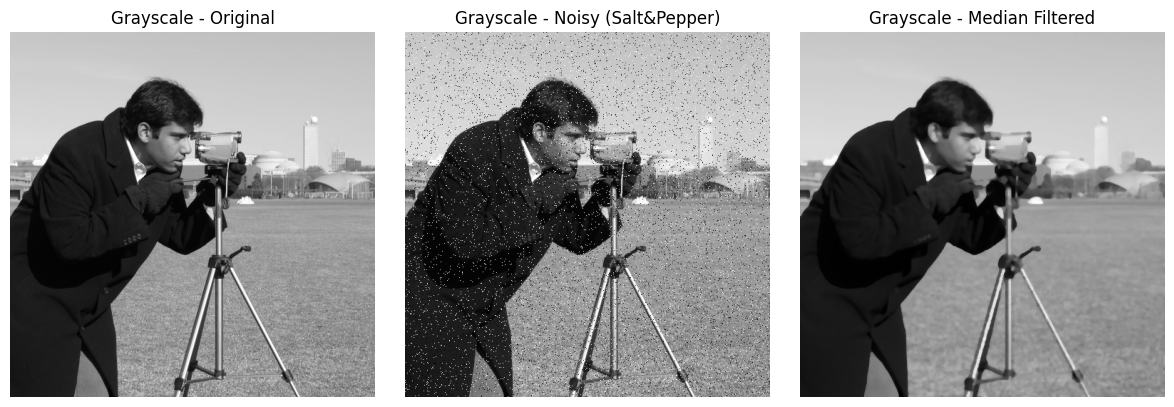

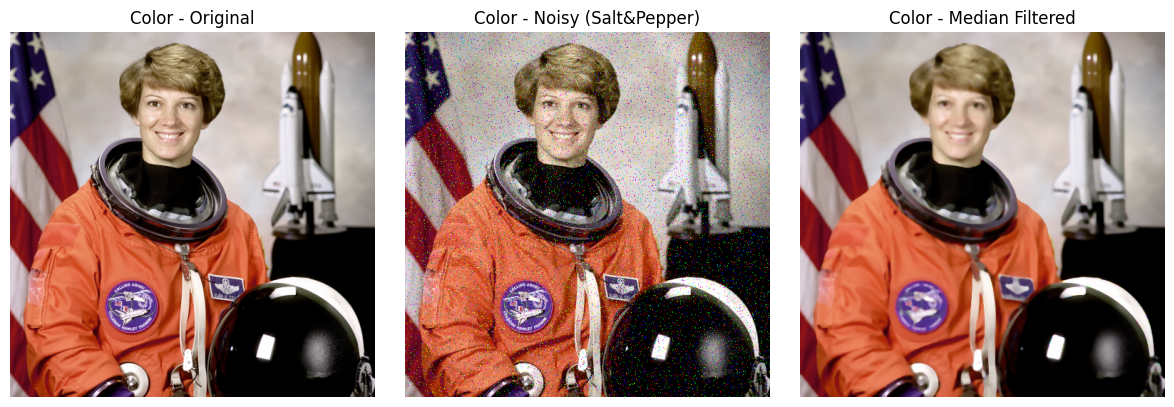

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

# -----------------------------------------
# 1) FILTER MEDIAN PADA CITRA GRAYSCALE
# -----------------------------------------

# A. Memuat citra grayscale (contoh: 'camera')
gray_uint8 = data.camera()  # grayscale, uint8
gray_float = img_as_float(gray_uint8)  # konversi float [0..1]

# B. Menambahkan noise jenis salt-and-pepper
gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05)  # amount=0.05 berarti 5% piksel terpengaruh noise

# C. Menerapkan filter median
# Kita gunakan structuring element berbentuk disk radius 3
disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

# D. Plot hasil
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy (Salt&Pepper)")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filtered")
axes[2].axis('off')

plt.tight_layout()
plt.show()

# -----------------------------------------
# 2) FILTER MEDIAN PADA CITRA BERWARNA
# -----------------------------------------

# A. Memuat citra berwarna (contoh: 'astronaut')
color_uint8 = data.astronaut()  # RGB, uint8
color_float = img_as_float(color_uint8)  # rentang [0..1]

# B. Menambahkan noise salt-and-pepper
color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

# C. Menerapkan filter median
# Pada scikit-image 0.19+, median() mampu menangani array 3D (RGB),
# atau kita bisa memanggil per kanal. Di sini langsung per-kanal:
color_denoised = np.zeros_like(color_noisy)
for c in range(color_noisy.shape[2]):
    color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

# D. Plot hasil
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_float)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy (Salt&Pepper)")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filtered")
axes2[2].axis('off')

plt.tight_layout()
plt.show()